In [2]:
!pip install opencv-python numpy

Live Color Sorting Started

Show RED, GREEN, or BLUE objects to the camera.

RED   -> Sorting Category A
GREEN -> Sorting Category B
BLUE  -> Sorting Category C

Stop the cell when you want to finish.


<IPython.core.display.Javascript object>

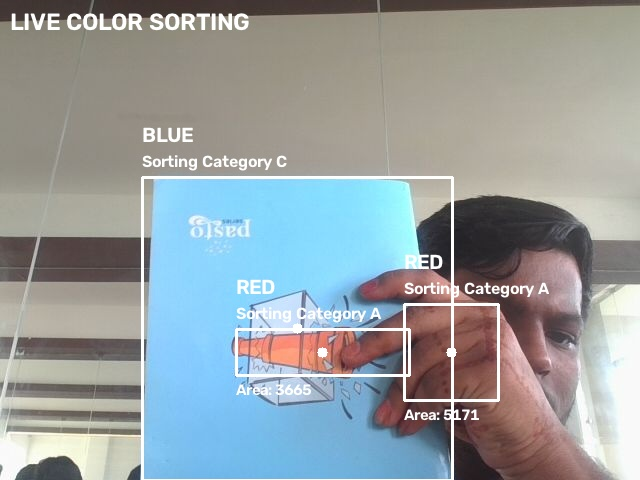

<IPython.core.display.Javascript object>

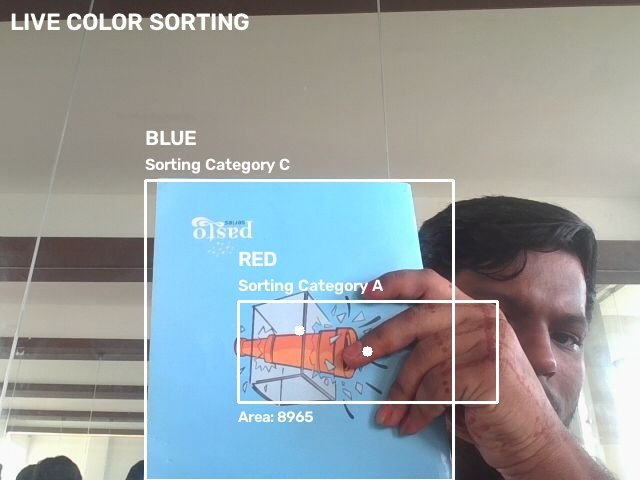

<IPython.core.display.Javascript object>

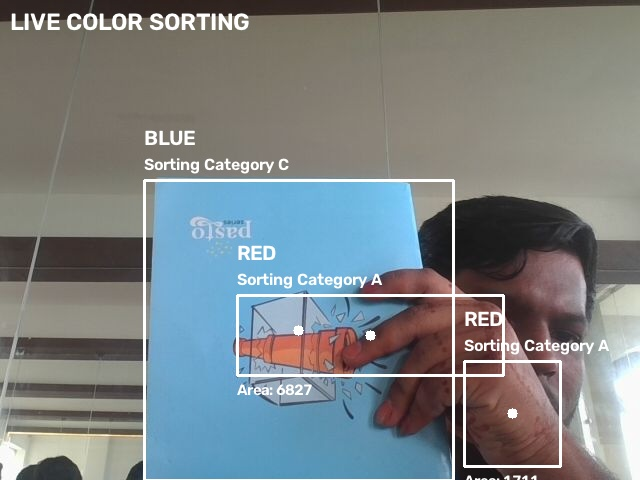

<IPython.core.display.Javascript object>


Processing stopped by user.
Live Color Sorting Stopped.


In [11]:
import cv2
import numpy as np
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode
import time

# ---------------------------------------------------------
# FUNCTION TO CAPTURE A FRAME FROM COLAB WEBCAM
# ---------------------------------------------------------

def take_photo():
    js = Javascript('''
    async function takePhoto() {

        const div = document.createElement('div');

        const video = document.createElement('video');
        video.style.display = 'block';
        video.width = 640;
        video.height = 480;

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;
        await video.play();

        // Wait for camera to initialize
        await new Promise(resolve => setTimeout(resolve, 1000));

        const canvas = document.createElement('canvas');

        canvas.width = 640;
        canvas.height = 480;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        stream.getVideoTracks()[0].stop();

        div.remove();

        return canvas.toDataURL('image/jpeg', 0.8);
    }

    takePhoto();
    ''')

    display(js)

    data = eval_js('takePhoto()')

    binary = b64decode(data.split(',')[1])

    return np.frombuffer(binary, dtype=np.uint8)


# ---------------------------------------------------------
# COLOR RANGES
# ---------------------------------------------------------

color_ranges = {

    "RED": [
        (
            np.array([0, 100, 100]),
            np.array([10, 255, 255])
        ),
        (
            np.array([170, 100, 100]),
            np.array([179, 255, 255])
        )
    ],

    "GREEN": [
        (
            np.array([35, 80, 80]),
            np.array([85, 255, 255])
        )
    ],

    "BLUE": [
        (
            np.array([90, 80, 80]),
            np.array([130, 255, 255])
        )
    ]
}


# ---------------------------------------------------------
# SORTING CATEGORIES
# ---------------------------------------------------------

sorting_categories = {

    "RED": "Sorting Category A",

    "GREEN": "Sorting Category B",

    "BLUE": "Sorting Category C"
}


# ---------------------------------------------------------
# MINIMUM OBJECT AREA
# ---------------------------------------------------------

MIN_AREA = 1000


# ---------------------------------------------------------
# MORPHOLOGICAL KERNEL
# ---------------------------------------------------------

kernel = np.ones((5, 5), np.uint8)


print("Live Color Sorting Started")
print()
print("Show RED, GREEN, or BLUE objects to the camera.")
print()
print("RED   -> Sorting Category A")
print("GREEN -> Sorting Category B")
print("BLUE  -> Sorting Category C")
print()
print("Stop the cell when you want to finish.")


# ---------------------------------------------------------
# MAIN PROCESSING LOOP
# ---------------------------------------------------------

try:

    while True:

        # Capture webcam image
        image_data = take_photo()

        # Decode image
        frame = cv2.imdecode(
            image_data,
            cv2.IMREAD_COLOR
        )

        if frame is None:
            print("Unable to read webcam frame.")
            continue


        # -------------------------------------------------
        # Convert BGR to HSV
        # -------------------------------------------------

        hsv = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2HSV
        )


        detections = []


        # -------------------------------------------------
        # PROCESS EACH COLOR
        # -------------------------------------------------

        for color_name, ranges in color_ranges.items():

            # Create empty mask
            mask = np.zeros(
                hsv.shape[:2],
                dtype=np.uint8
            )


            # Apply color thresholds
            for lower, upper in ranges:

                current_mask = cv2.inRange(
                    hsv,
                    lower,
                    upper
                )

                mask = cv2.bitwise_or(
                    mask,
                    current_mask
                )


            # -------------------------------------------------
            # REMOVE NOISE
            # -------------------------------------------------

            mask = cv2.morphologyEx(
                mask,
                cv2.MORPH_OPEN,
                kernel
            )

            mask = cv2.morphologyEx(
                mask,
                cv2.MORPH_CLOSE,
                kernel
            )


            # -------------------------------------------------
            # FIND CONTOURS
            # -------------------------------------------------

            contours, _ = cv2.findContours(
                mask,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )


            # -------------------------------------------------
            # PROCESS CONTOURS
            # -------------------------------------------------

            for contour in contours:

                area = cv2.contourArea(contour)


                # Ignore small objects/noise
                if area < MIN_AREA:
                    continue


                # Bounding rectangle
                x, y, w, h = cv2.boundingRect(
                    contour
                )


                # Center point
                center_x = x + w // 2
                center_y = y + h // 2


                # Sorting category
                category = sorting_categories[
                    color_name
                ]


                detections.append(
                    (
                        color_name,
                        category,
                        x,
                        y,
                        w,
                        h,
                        center_x,
                        center_y,
                        area
                    )
                )


        # -------------------------------------------------
        # DRAW DETECTIONS
        # -------------------------------------------------

        for detection in detections:

            (
                color_name,
                category,
                x,
                y,
                w,
                h,
                center_x,
                center_y,
                area
            ) = detection


            # Bounding box
            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (255, 255, 255),
                2
            )


            # Color name
            cv2.putText(
                frame,
                color_name,
                (x, y - 35),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2
            )


            # Sorting category
            cv2.putText(
                frame,
                category,
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (255, 255, 255),
                2
            )


            # Center point
            cv2.circle(
                frame,
                (center_x, center_y),
                5,
                (255, 255, 255),
                -1
            )


            # Area
            cv2.putText(
                frame,
                f"Area: {int(area)}",
                (x, y + h + 20),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 255, 255),
                2
            )


        # -------------------------------------------------
        # DISPLAY INFORMATION
        # -------------------------------------------------

        cv2.putText(
            frame,
            "LIVE COLOR SORTING",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2
        )


        # -------------------------------------------------
        # DISPLAY PROCESSED FRAME IN COLAB
        # -------------------------------------------------

        _, buffer = cv2.imencode(
            '.jpg',
            frame
        )

        display(
            Image(
                data=buffer.tobytes()
            )
        )


        # Small delay
        time.sleep(0.2)


except KeyboardInterrupt:

    print("\nProcessing stopped by user.")


print("Live Color Sorting Stopped.")